In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [1]:
import tensorflow as tf
print(tf.__version__)

2.16.2


In [3]:
#seeding libraries
#there is always randomness during training (because during train-test, the data is split differently everytime), so setting seeds for reproducibility
import random #library
random.seed(0) #can be any number, not just 0

import numpy as np 
np.random.seed(0)

import tensorflow as tf 
tf.random.set_seed(0)

In [ ]:
#importing dependencies
#keras: api that makes NN training easier, supports TF and pytorch, importing dataset, layers (cnn has multiple layers), models (to save models, etc)
from tensorflow.keras import datasets, layers, models
#to plot images and draw conclusions
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [9]:
#data curation
#loading and preparing fashion MIST dataset

fashion_mnist = datasets.fashion_mnist #getting data from dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data() #load training and test data to train_images(image data in the form of numpy array) and train_labels(labels of those images 0,1,2,...) tuples

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Data Processing
- Getting information about data types and lengths before proceeding with training

In [12]:
type(train_images)

numpy.ndarray

In [13]:
type(train_labels)

numpy.ndarray

In [14]:
print(len(train_images))

60000


In [15]:
print(len(train_labels))

60000


In [ ]:
#taking first element in train_images and seeing what the shape is going to be
print(train_images[0].shape) #numpy array
#output: (height, width)
#all images are 28x28 in dimension (code differs if want to handle diff diemension images)
#output has no 3rd channel for rgb meaning its a greyscale dataset, otherwise it wouldve been (height, width, rgb)
# 0= black, 255= white, numbers in b/w = intensity of white color

(28, 28)


In [17]:
print(train_images[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [18]:
print(type(train_images[0]))

<class 'numpy.ndarray'>


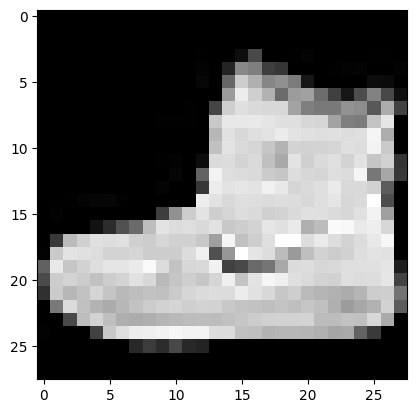

In [ ]:
#displaying numpy_array as an image from the dataset
plt.imshow(train_images[0], cmap='gray') #fashion-mnist contains images in greyscale
plt.show()

In [ ]:
#corresponding label for aboive img
print(train_labels[0])
#list of possible labels: 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot' index: 0-9)

9


In [21]:
#normalizing (having values within specific range) pixel values to be between 0 and 1 (before normalization its between 0-255)
#dividing each value by 255:
train_images, test_images = train_images / 255.0, test_images / 255.0
#shorter range -> performance and efficiency becomes better, reduces risk of the model being stuck at local optimum (thinks its the best parameter it can get)

In [23]:
#checking above output
print(train_images[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.00392157 0.    

In [ ]:
# reshaping images to specify it's a single channel (greyscale)
#tf requires data to have 4 dimensions (num of images, height, width, channel info)
#channel info = 1 if grey, 3 if rgb
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

In [25]:
train_images.shape

(60000, 28, 28, 1)

In [26]:
test_images.shape

(10000, 28, 28, 1)

In [27]:
#building the convolutional base
model = models.Sequential() #Sequential is used to stack layers one of top of the other, each layer feeds data into the next layer 
#Conv2D: 2D convolutional layer, 32 filters/kernels, (3,3) is size of matrix, 'relu': recitify linear units, input_shape(height, width, color channel) 
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
#MaxPooling is a 2D layer used to reduce spatial dimensions so that its easier for the model to understand it and recognize things better
model.add(layers.MaxPooling2D((2, 2)))
#going deeper into the layers, we're increasing the number of filters/kernels from 32 -> 64 so that the model can recognize minute information present in data 
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

#now we have a 3x3 matrix of layers and before moving fwrd we need to flatten them so that it becomes a vector (a single array)

#adding Dense layers on top
model.add(layers.Flatten()) #1D array
model.add(layers.Dense(64, activation='relu')) #connecting all neurons of prev layer to Dense layer
model.add(layers.Dense(10)) #output/top layer that identifies image as belonging to a class/category, no activation mentioned meaning activation is linear (default), using 10 bc thats the number of classes/categories we have


/Users/aarushibhargava/Desktop/fashion-mnist-cnn/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-17 10:01:40.826508: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-17 10:01:40.827152: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-17 10:01:40.827411: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-17 10:01:40.827595: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-17 10:01:40.828021: I tensorflow/core/common_runtime/pluggable_devi

In [ ]:
#compiling the model -> making the model ready for training 
#optimizer: finds best parameters for model that follows a gradient descent pattern 
model.compile(optimizer='adam',
                                    #does binary encoding of classes, logits: True when output is not in the form of probability
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              #metrics its going to train on is accuracy
              metrics=['accuracy'])

In [29]:
#model training
                     
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))
#output: accuracy, loss, val_accuracy, val_loss

Epoch 1/5


2026-03-17 10:16:18.291151: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 33ms/step - accuracy: 0.8130 - loss: 0.5095 - val_accuracy: 0.8674 - val_loss: 0.3779
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8793 - loss: 0.3336 - val_accuracy: 0.8760 - val_loss: 0.3449
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.8948 - loss: 0.2924 - val_accuracy: 0.8892 - val_loss: 0.3177
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9032 - loss: 0.2691 - val_accuracy: 0.8916 - val_loss: 0.3171
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9086 - loss: 0.2585 - val_accuracy: 0.8926 - val_loss: 0.3276


In [ ]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)
#output: accuracy, loss, Test accuracy

313/313 - 3s - 9ms/step - accuracy: 0.8926 - loss: 0.3276

Test accuracy: 0.8925999999046326


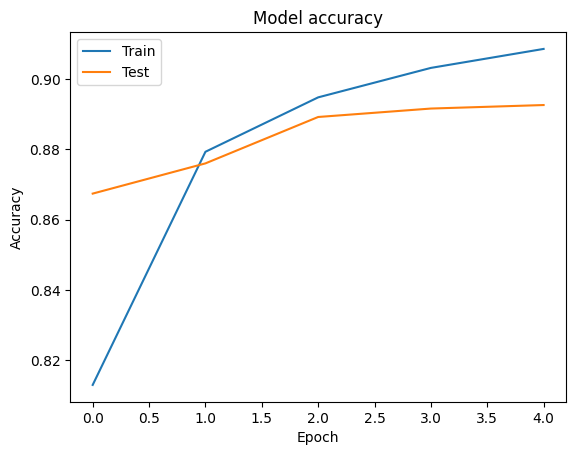

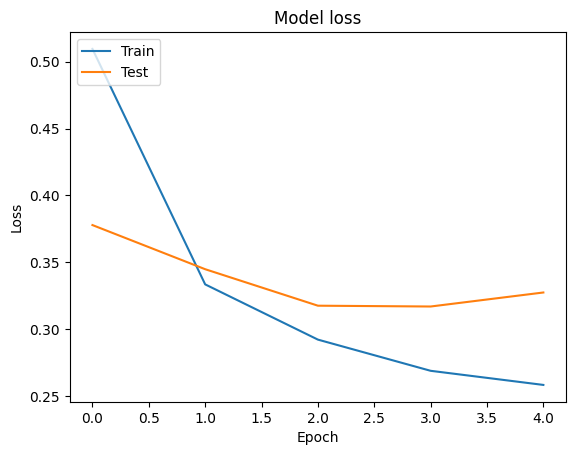

In [ ]:
#plotting: training and validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc="upper left")
plt.show()

#expected outcome: model's accuracy should increase over epoch

#plotting: training & validating loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc="upper left")
plt.show()

#expected outcome: model's loss should decrease over epoch


In [34]:
model.save('trained_fashion_mnist_model.h5')